<a href="https://colab.research.google.com/github/yai95/ML/blob/main/Clasificador_de_la_enfermed_de_Alzheimer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de la Enfermedad del Alzheimer



In [ ]:
import tensorflow as tf
device_name=tf.test.gpu_device_name()

if device_name != '/device:GPU:0':
  raise SystemError('No hay GPU')
print('Found GPU at: {}' .format(device_name))

Found GPU at: /device:GPU:0


In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Select the Runtime > "Change runtime type" menu to enable a GPU accelerator, ')
  print('and then re-execute this cell.')
else:
  print(gpu_info)

Sun Feb 27 00:14:11 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   39C    P0    27W /  70W |    264MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [ ]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('To enable a high-RAM runtime, select the Runtime > "Change runtime type"')
  print('menu, and then select High-RAM in the Runtime shape dropdown. Then, ')
  print('re-execute this cell.')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 13.6 gigabytes of available RAM

To enable a high-RAM runtime, select the Runtime > "Change runtime type"
menu, and then select High-RAM in the Runtime shape dropdown. Then, 
re-execute this cell.


## Librerias

In [ ]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import statistics
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2
from imblearn.metrics import specificity_score
from sklearn.metrics import roc_curve
from tensorflow.keras.regularizers import l2
from tensorflow.keras.regularizers import l1
from tensorflow.keras.utils import to_categorical
from keras.utils.vis_utils import plot_model
from keras.models import Sequential,Input,Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Convolution2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Convolution3D, MaxPooling3D
from tensorflow.keras.optimizers import SGD, RMSprop, Adam,Adadelta
from tensorflow.keras.layers import Dense
from numpy import dstack
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Dropout
from sklearn.metrics import roc_auc_score
import seaborn as sns
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import GRU
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.layers import TimeDistributed
from tensorflow.keras.layers import Bidirectional
from sklearn.model_selection import KFold
from matplotlib import pyplot
from numpy import mean
from numpy import std
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
import numpy
from numpy import array
from numpy import argmax
from keras.models import load_model
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
import nibabel as nib
from skimage.transform import resize
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from scipy import ndimage
import glob

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


##  Cargar las imágenes PET

In [ ]:
AD=glob.glob("/content/gdrive/My Drive/AD/*.nii")
MCI=glob.glob("/content/gdrive/My Drive/MCI/*.nii")
NOR=glob.glob("/content/gdrive/My Drive/NOR/*.nii")
lista_de_archivos=AD+MCI+NOR

In [ ]:
len(AD),len(MCI),len(NOR)

(70, 111, 68)

###  Cortes en los diferentes planos de una imagen PET (Sagital,Coronal,Axial)

In [ ]:
lectura_imagenPET=nib.load(lista_de_archivos[25])
imagenPET=lectura_imagenPET.get_data()


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: DeprecationWarning: get_data() is deprecated in favor of get_fdata(), which has a more predictable return type. To obtain get_data() behavior going forward, use numpy.asanyarray(img.dataobj).

* deprecated from version: 3.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 5.0
  
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: DeprecationWarning: get_data() is deprecated in favor of get_fdata(), which has a more predictable return type. To obtain get_data() behavior going forward, use numpy.asanyarray(img.dataobj).

* deprecated from version: 3.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 5.0
  after removing the cwd from sys.path.


In [ ]:
slice_coronal = imagenPET[:, 30, :]
slice_axial = imagenPET[:, :, 10]
slice_sagital = imagenPET[40, :, :]

Text(0.5, 1.0, 'Plano Axial')

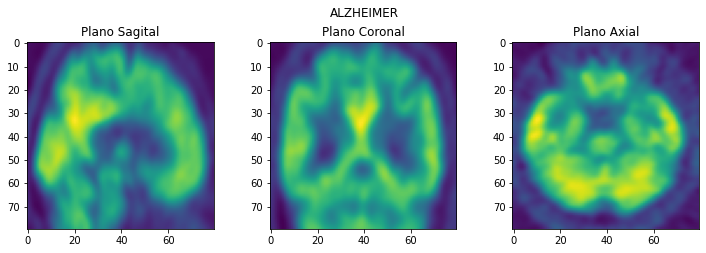

In [ ]:
fig, ((axs,axs1,axs2)) = plt.subplots(1, 3,figsize=(12,7))
fig.tight_layout()
fig.subplots_adjust(left=0.2, wspace=0.3,hspace=0.3, top=0.9)

axs.imshow(ndimage.rotate(resize(slice_sagital,(80,80)), 90))
axs.set_title('Plano Sagital')
axs1.annotate('ALZHEIMER',(10,0.8), fontsize=12,# this is the point to label
                 textcoords="offset points", # how to position the text
                 xytext=(70,28), # distance from text to points (x,y)
                 ha='center')
axs1.imshow(ndimage.rotate(resize(slice_coronal,(80,80)), 90))
axs1.set_title('Plano Coronal')
axs2.imshow(ndimage.rotate(resize(slice_axial,(80,80)), 90))
axs2.set_title('Plano Axial')


### Reescala

Text(0.5, 1.0, 'Imagen reescalada a un tamaño inferior')

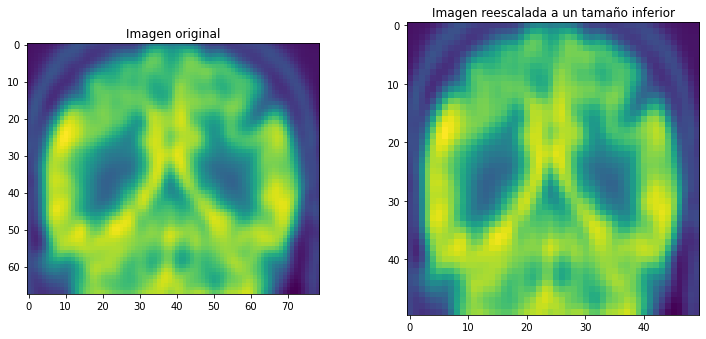

In [ ]:
fig, ((axs,axs1)) = plt.subplots(1, 2,figsize=(12,7))
fig.tight_layout()
fig.subplots_adjust(left=0.2, wspace=0.3,hspace=0.3, top=0.9)

axs.imshow(ndimage.rotate(slice_coronal, 90))
axs.set_title('Imagen original')
axs1.imshow(ndimage.rotate(resize(slice_coronal,(50,50)), 90))
axs1.set_title('Imagen reescalada a un tamaño inferior')


### Comparativa entre dos imagenes

Text(0.5, 1.0, 'Plano Axial')

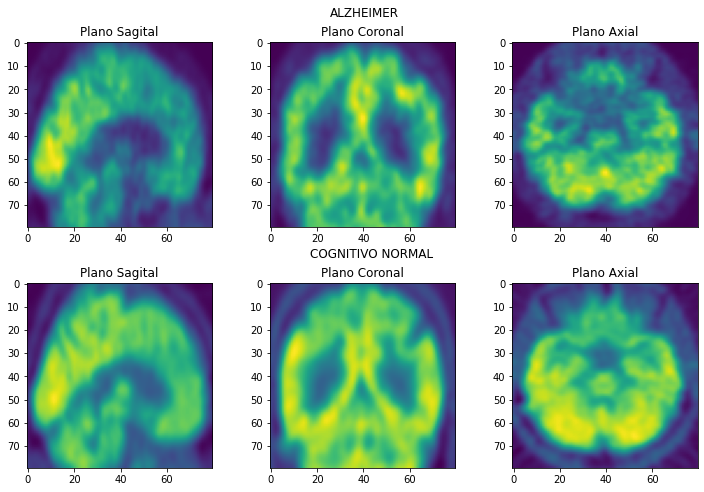

In [ ]:
fig, ((axs,axs1,axs2),(axs3,axs4,axs5)) = plt.subplots(2, 3,figsize=(12,7))
fig.tight_layout()
fig.subplots_adjust(left=0.2, wspace=0.3,hspace=0.3, top=0.9)

axs.imshow(ndimage.rotate(resize(slice_sagital,(80,80)), 90))
axs.set_title('Plano Sagital')
axs1.annotate('ALZHEIMER',(10,0.8), fontsize=12,# this is the point to label
                 textcoords="offset points", # how to position the text
                 xytext=(70,28), # distance from text to points (x,y)
                 ha='center')
axs1.imshow(ndimage.rotate(resize(slice_coronal,(80,80)), 90))
axs1.set_title('Plano Coronal')
axs2.imshow(ndimage.rotate(resize(slice_axial,(80,80)), 90))
axs2.set_title('Plano Axial')
axs3.annotate('COGNITIVO NORMAL',(10,0.8), fontsize=12,# this is the point to label
                 textcoords="offset points", # how to position the text
                 xytext=(320,28), # distance from text to points (x,y)
                 ha='center')
axs3.imshow(ndimage.rotate(resize(slice_sagital1,(80,80)), 90))
axs3.set_title('Plano Sagital')
axs4.imshow(ndimage.rotate(resize(slice_coronal1,(80,80)), 90))
axs4.set_title('Plano Coronal')
axs5.imshow(ndimage.rotate(resize(slice_axial1,(80,80)), 90))
axs5.set_title('Plano Axial')

### Preparación y prepocesamiento de las imágenes PET

In [ ]:
def images_mci_y_normales(Lista,long):
    i=0
    images_plano_coronal=[]
    labels=[]
    while i<len(Lista):
            lectura_imagen_PET=nib.load(Lista[i])
            obtener_datos=lectura_imagen_PET.get_fdata()
            obtener_datos[np.isnan(obtener_datos)]=0
            cortes_imagen_plano_coronal=[]
            k=10
            while k<80:
                slice_imagen = obtener_datos[:, k, :]
                imagen_reducida=resize(slice_imagen, (50,50))
                cortes_imagen_plano_coronal.append(imagen_reducida)

                k=k+4
            if i<len(long):
                labels.append(1)## Clase AD o MCI
            if i>=len(long):
                labels.append(0)## Clase NOR
            lista_a_array=np.array(cortes_imagen_plano_coronal)
            images_plano_coronal.append(lista_a_array)
            i=i+1
    return images_plano_coronal,labels

In [ ]:
def tensor_entrada(images,labels):
  input_image=np.array(images)
  y=np.array(labels)
  X = input_image[:, :, :,:, np.newaxis]
  minimo=np.min(X)
  maximo=np.max(X)
  X_norm=(X-minimo)/(maximo-minimo)
  return X_norm,y

In [ ]:
images_coronal,labels=images_mci_y_normales(lista_de_archivos,AD)

In [ ]:
X,y=tensor_entrada(images_coronal,labels)

In [ ]:
X.shape,y.shape

((179, 18, 50, 50, 1), (179,))

In [ ]:
minimo=np.min(X)
maximo=np.max(X)
minimo,maximo

(0.0, 1.0)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.0, random_state=7)

In [ ]:
X_train.shape,y_train.shape

((137, 18, 50, 50, 1), (137,))

In [ ]:
y_train

array([0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 1])

## Arquitectura de red : CNN+GRU

In [ ]:
def cnn(init_mode,dr_2,dr_1,activacion,neuronas):
    kernel_size =5  # Size of the kernel for the convolution layers
    pool_size = 2 # Size of the pooling region for the pooling layers

    cnn=Sequential()
    cnn.add(Convolution2D(8, # Number convolution channels to generate
                            (kernel_size, kernel_size),kernel_initializer=init_mode, # Size of convolution kernels
                             input_shape=(50,50,1))) # Size = image rows x image columns x channels
    cnn.add(BatchNormalization())
    cnn.add(Activation(activacion))
    cnn.add(Convolution2D(16, (kernel_size, kernel_size),kernel_initializer=init_mode))
    cnn.add(BatchNormalization())
    cnn.add(Activation(activacion))
    cnn.add(MaxPooling2D(pool_size=(pool_size, pool_size)))
    cnn.add(Dropout(dr_1))

    cnn.add(Convolution2D(neuronas, (kernel_size, kernel_size),kernel_initializer=init_mode))
    cnn.add(Activation(activacion))
    cnn.add(BatchNormalization())
    cnn.add(MaxPooling2D(pool_size=(pool_size, pool_size)))
    cnn.add(Dropout(dr_2))

    cnn.add(Flatten())
    return cnn

In [ ]:
def create_model(init_mode='glorot_uniform',optimizer='Adam',activacion='relu',activation1='tanh',dr_3=0.1,l_rate=0.001,dr_2=0.0,dr_1=0.0,neuronas=32,unidades=32,l2_rate=0.01):
    # define model
    model=Sequential()
    model.add(TimeDistributed(cnn(init_mode,dr_2,dr_1,activacion,neuronas),input_shape=(18,50,50,1)))
    model.add(GRU(unidades,kernel_initializer=init_mode,kernel_regularizer=l2(l_rate),return_sequences=False))
    model.add(Activation(activation1))
    model.add(BatchNormalization())
    model.add(Dropout(dr_3))
    model.add(Dense(2,kernel_initializer=init_mode))

    model.add(Activation('softmax'))
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

In [ ]:
modelo = KerasClassifier(build_fn=create_model, epochs=80, batch_size=32, verbose=1)

### Búsqueda de Cuadrícula

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold
layer_size = [32,64,128,256]
neuronas = [8,16,32,64]
unidades = [8,16,32,64]
activacion=['relu','tanh','linear']
activation=['relu','tanh']
dr_1 = [0.0,0.1,0.2,0.3]
dr_2 = [0.0,0.1,0.2,0.3,0.4]
dr_3 = [0.0,0.1,0.2,0.3,0.4]

l1_rate=[0.1,0.001,0.0001,0.00001]
l2_rate=[0.001,0.0001,0.00001]
l3_rate=[0.01,0.001,0.0001,0.00001,0.000001]
l_rate=[0.001,0.0001,0.00001]
weight_constraint = [1, 2, 3, 4, 5]
weight_constraint2 = [1, 2, 3, 4, 5]

init_mode = ['glorot_uniform','he_uniform','normal']
optimizer = ['Adagrad', 'Adamax','Adadelta','Adam']
##############################################################
# grid search epochs, batch size
epochs = [80,90,100] # add 50, 100, 150 etc
batch_size = [32,48] # add 5, 10, 20, 40, 60, 80, 100 etc
param_grid = dict(dr_1=dr_1,dr_2=dr_2,epochs=epochs,l_rate=l_rate)
n_folds = 10
kfold =StratifiedKFold(n_splits=10, shuffle=True, random_state=2)
grid = GridSearchCV(estimator=modelo, param_grid=param_grid, n_jobs=-1,cv=kfold)

In [ ]:
grid_result = grid.fit(X_train,y_train)

/usr/local/lib/python3.6/dist-packages/joblib/externals/loky/process_executor.py:691: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  "timeout or by a memory leak.", UserWarning


Epoch 1/90
5/5 [==============================] - 0s 34ms/step - loss: 0.8700 - accuracy: 0.5328
Epoch 2/90
5/5 [==============================] - 0s 24ms/step - loss: 0.6293 - accuracy: 0.7080
Epoch 3/90
5/5 [==============================] - 0s 25ms/step - loss: 0.6882 - accuracy: 0.6131
Epoch 4/90
5/5 [==============================] - 0s 24ms/step - loss: 0.4369 - accuracy: 0.7883
Epoch 5/90
5/5 [==============================] - 0s 25ms/step - loss: 0.4756 - accuracy: 0.7810
Epoch 6/90
5/5 [==============================] - 0s 24ms/step - loss: 0.4344 - accuracy: 0.7956
Epoch 7/90
5/5 [==============================] - 0s 24ms/step - loss: 0.3968 - accuracy: 0.8029
Epoch 8/90
5/5 [==============================] - 0s 24ms/step - loss: 0.3444 - accuracy: 0.8321
Epoch 9/90
5/5 [==============================] - 0s 24ms/step - loss: 0.3485 - accuracy: 0.8467
Epoch 10/90
5/5 [==============================] - 0s 24ms/step - loss: 0.2395 - accuracy: 0.9124
Epoch 11/90
5/5 [============

In [ ]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.905495 using {'dr_1': 0.1, 'dr_2': 0.4, 'l2_rate': 1e-05, 'l_rate': 0.001}
0.882967 (0.084123) with: {'dr_1': 0.0, 'dr_2': 0.0, 'l2_rate': 0.001, 'l_rate': 0.001}
0.810440 (0.087266) with: {'dr_1': 0.0, 'dr_2': 0.0, 'l2_rate': 0.001, 'l_rate': 0.0001}
0.839011 (0.094533) with: {'dr_1': 0.0, 'dr_2': 0.0, 'l2_rate': 0.001, 'l_rate': 1e-05}
0.838462 (0.081467) with: {'dr_1': 0.0, 'dr_2': 0.0, 'l2_rate': 0.001, 'l_rate': 1e-06}
0.840659 (0.094531) with: {'dr_1': 0.0, 'dr_2': 0.0, 'l2_rate': 0.0001, 'l_rate': 0.001}
0.861538 (0.049803) with: {'dr_1': 0.0, 'dr_2': 0.0, 'l2_rate': 0.0001, 'l_rate': 0.0001}
0.839011 (0.109534) with: {'dr_1': 0.0, 'dr_2': 0.0, 'l2_rate': 0.0001, 'l_rate': 1e-05}
0.860989 (0.052302) with: {'dr_1': 0.0, 'dr_2': 0.0, 'l2_rate': 0.0001, 'l_rate': 1e-06}
0.803846 (0.094501) with: {'dr_1': 0.0, 'dr_2': 0.0, 'l2_rate': 1e-05, 'l_rate': 0.001}
0.824725 (0.074306) with: {'dr_1': 0.0, 'dr_2': 0.0, 'l2_rate': 1e-05, 'l_rate': 0.0001}
0.854396 (0.077869) with: {'dr

In [ ]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.905494 using {'batch_size': 32, 'dr_1': 0.2, 'dr_2': 0.3, 'l_rate': 0.001}
0.868132 (0.071976) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.0, 'l_rate': 0.001}
0.817582 (0.095225) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.0, 'l_rate': 0.0001}
0.853846 (0.085623) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.0, 'l_rate': 1e-05}
0.840110 (0.094896) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.0, 'l_rate': 1e-06}
0.847253 (0.112276) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.1, 'l_rate': 0.001}
0.891209 (0.058034) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.1, 'l_rate': 0.0001}
0.817033 (0.089040) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.1, 'l_rate': 1e-05}
0.868132 (0.071976) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.1, 'l_rate': 1e-06}
0.845055 (0.106565) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.2, 'l_rate': 0.001}
0.838462 (0.079441) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.2, 'l_rate': 0.0001}
0.890110 (0.068096) with: {'batch_

In [ ]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.898901 using {'batch_size': 32, 'dr_1': 0.2, 'dr_2': 0.2, 'l_rate': 0.0001}
0.825824 (0.082236) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.0, 'l_rate': 0.001}
0.825275 (0.109168) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.0, 'l_rate': 0.0001}
0.869231 (0.103606) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.0, 'l_rate': 1e-05}
0.840110 (0.086334) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.0, 'l_rate': 1e-06}
0.868681 (0.079146) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.1, 'l_rate': 0.001}
0.891209 (0.075729) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.1, 'l_rate': 0.0001}
0.803846 (0.097890) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.1, 'l_rate': 1e-05}
0.863187 (0.059556) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.1, 'l_rate': 1e-06}
0.854396 (0.086082) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.2, 'l_rate': 0.001}
0.832418 (0.075427) with: {'batch_size': 32, 'dr_1': 0.0, 'dr_2': 0.2, 'l_rate': 0.0001}
0.876923 (0.080648) with: {'batch

### La mejor configuración del modelo

In [ ]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.919231 using {'dr_1': 0.0, 'dr_2': 0.3, 'epochs': 90, 'l_rate': 1e-05}
0.822527 (0.123914) with: {'dr_1': 0.0, 'dr_2': 0.0, 'epochs': 80, 'l_rate': 0.001}
0.867582 (0.122946) with: {'dr_1': 0.0, 'dr_2': 0.0, 'epochs': 80, 'l_rate': 0.0001}
0.867033 (0.093626) with: {'dr_1': 0.0, 'dr_2': 0.0, 'epochs': 80, 'l_rate': 1e-05}
0.853297 (0.103933) with: {'dr_1': 0.0, 'dr_2': 0.0, 'epochs': 90, 'l_rate': 0.001}
0.795055 (0.113540) with: {'dr_1': 0.0, 'dr_2': 0.0, 'epochs': 90, 'l_rate': 0.0001}
0.837363 (0.119326) with: {'dr_1': 0.0, 'dr_2': 0.0, 'epochs': 90, 'l_rate': 1e-05}
0.831319 (0.087673) with: {'dr_1': 0.0, 'dr_2': 0.0, 'epochs': 100, 'l_rate': 0.001}
0.881868 (0.061295) with: {'dr_1': 0.0, 'dr_2': 0.0, 'epochs': 100, 'l_rate': 0.0001}
0.823077 (0.112303) with: {'dr_1': 0.0, 'dr_2': 0.0, 'epochs': 100, 'l_rate': 1e-05}
0.823626 (0.132290) with: {'dr_1': 0.0, 'dr_2': 0.1, 'epochs': 80, 'l_rate': 0.001}
0.867582 (0.072663) with: {'dr_1': 0.0, 'dr_2': 0.1, 'epochs': 80, 'l_rate'

In [ ]:
def create_model():
    # define model
    kernel_size =5  # Size of the kernel for the convolution layers
    pool_size = 2 # Size of the pooling region for the pooling layers
    init_mode='glorot_uniform'
    activacion='relu'
    model=Sequential(name="Modelo_Clasificación")


    model.add(TimeDistributed(Convolution2D(8, # Number convolution channels to generate
                            (kernel_size, kernel_size),kernel_initializer=init_mode,activation=activacion),name="Conv2D_1", # Size of convolution kernels
                             input_shape=(18,50,50,1))) # Size = image rows x image columns x channels
    model.add(BatchNormalization(name="BatchNormalization_1"))

    model.add(TimeDistributed(Convolution2D(16, (kernel_size, kernel_size),kernel_initializer=init_mode,activation=activacion),name="Conv2D_2"))
    model.add(BatchNormalization(name="BatchNormalization_2"))

    model.add(TimeDistributed(MaxPooling2D(pool_size=(pool_size, pool_size)),name="MaxPooling_1"))

    model.add(TimeDistributed(Convolution2D(32, (kernel_size, kernel_size),kernel_initializer=init_mode,activation=activacion),name="Conv2D_3"))

    model.add(BatchNormalization(name="BatchNormalization_3"))
    model.add(TimeDistributed(MaxPooling2D(pool_size=(pool_size, pool_size)),name="MaxPooling_2"))
    model.add(TimeDistributed(Dropout(0.3),name="Dropout_1"))

    model.add(TimeDistributed(Flatten(),name="Flatten"))

    model.add(GRU(32,kernel_initializer=init_mode,kernel_regularizer=l2(1e-5),activation='tanh', name="GRU",return_sequences=False))

    model.add(BatchNormalization(name="BatchNormalization_4"))
    model.add(Dropout(0.1,name="Dropout_2"))
    model.add(Dense(2,kernel_initializer=init_mode,activation='softmax',name="Dense"))


    return model

In [ ]:
create_model().summary(line_length=60 )

Model: "Modelo_Clasificación"
____________________________________________________________
Layer (type)               Output Shape            Param #  
Conv2D_1 (TimeDistributed) (None, 18, 46, 46, 8)   208      
____________________________________________________________
BatchNormalization_1 (Batc (None, 18, 46, 46, 8)   32       
____________________________________________________________
Conv2D_2 (TimeDistributed) (None, 18, 42, 42, 16)  3216     
____________________________________________________________
BatchNormalization_2 (Batc (None, 18, 42, 42, 16)  64       
____________________________________________________________
MaxPooling_1 (TimeDistribu (None, 18, 21, 21, 16)  0        
____________________________________________________________
Conv2D_3 (TimeDistributed) (None, 18, 17, 17, 32)  12832    
____________________________________________________________
BatchNormalization_3 (Batc (None, 18, 17, 17, 32)  128      
_______________________________________________________

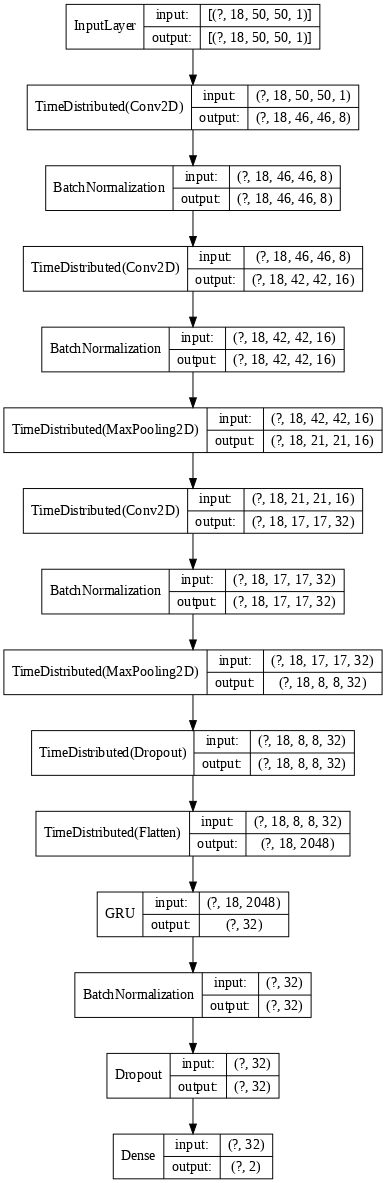

In [ ]:
model=create_model()
plot_model(model,show_shapes=True,expand_nested=False,to_file='model_plot.png' ,show_layer_names=False,dpi=70)

## Evaluación del Modelo con el cjto de hiperparámetros que ha conseguido la mejor capacidad predictiva





In [ ]:
def cnn():
    kernel_size =5  # Size of the kernel for the convolution layers
    pool_size = 2 # Size of the pooling region for the pooling layers
    init_mode='glorot_uniform'
    activacion='relu'
    cnn=Sequential()
    cnn.add(Convolution2D(8, # Number convolution channels to generate
                            (kernel_size, kernel_size),kernel_initializer=init_mode, # Size of convolution kernels
                             input_shape=(50,50,1))) # Size = image rows x image columns x channels
    cnn.add(BatchNormalization())
    cnn.add(Activation(activacion))
    cnn.add(Convolution2D(16, (kernel_size, kernel_size),kernel_initializer=init_mode))
    cnn.add(BatchNormalization())
    cnn.add(Activation(activacion))
    cnn.add(MaxPooling2D(pool_size=(pool_size, pool_size)))
    cnn.add(Dropout(0.0))

    cnn.add(Convolution2D(32, (kernel_size, kernel_size),kernel_initializer=init_mode))
    cnn.add(Activation(activacion))
    cnn.add(BatchNormalization())
    cnn.add(MaxPooling2D(pool_size=(pool_size, pool_size)))
    cnn.add(Dropout(0.3))

    cnn.add(Flatten())
    return cnn

In [ ]:
def evaluate_model(Xtrain, Ytrain, Xval, Yval):

    trainy_enc = to_categorical(Ytrain)
    valy_enc = to_categorical(Yval)
    K.clear_session()
    model=Sequential()
    model.add(TimeDistributed(cnn(),input_shape=(18,50,50,1)))
    model.add(GRU(32,kernel_initializer='glorot_uniform',kernel_regularizer=l2(1e-5),return_sequences=False))
    model.add(Activation('tanh'))
    model.add(BatchNormalization())
    model.add(Dropout(0.1))
    model.add(Dense(2,kernel_initializer='glorot_uniform'))
    model.add(Activation('softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
    history=model.fit(
        Xtrain, # Training data
        trainy_enc, # Labels of training data
        validation_data=(Xval,valy_enc),
        batch_size=32, # Batch size for the optimizer algorithm
        epochs=90, # Number of epochs to run the optimizer algorithm
        verbose=2 # Level of verbosity of the log messages
    )
    _,test_acc = model.evaluate(Xval, valy_enc, verbose=0)
    y_pred=model.predict(Xval,verbose=0)
    Y_pred=np.argmax(y_pred,axis=1)
    score=accuracy_score(Yval,Y_pred)
    return test_acc,history,model

#  AD vs CN

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1)

In [ ]:
test,hist,model=evaluate_model(X_train,y_train,X_test,y_test)
test1,hist1,model1=evaluate_model(X_train,y_train,X_test,y_test)
test2,hist2,model2=evaluate_model(X_train,y_train,X_test,y_test)


Epoch 1/90
4/4 - 1s - loss: 0.9759 - accuracy: 0.4957 - val_loss: 0.7398 - val_accuracy: 0.3810
Epoch 2/90
4/4 - 0s - loss: 0.7064 - accuracy: 0.6154 - val_loss: 0.7286 - val_accuracy: 0.3810
Epoch 3/90
4/4 - 0s - loss: 0.5671 - accuracy: 0.7094 - val_loss: 0.6924 - val_accuracy: 0.5714
Epoch 4/90
4/4 - 0s - loss: 0.5030 - accuracy: 0.7265 - val_loss: 0.6705 - val_accuracy: 0.6190
Epoch 5/90
4/4 - 0s - loss: 0.4084 - accuracy: 0.8120 - val_loss: 0.6741 - val_accuracy: 0.6190
Epoch 6/90
4/4 - 0s - loss: 0.3848 - accuracy: 0.8376 - val_loss: 0.6892 - val_accuracy: 0.6190
Epoch 7/90
4/4 - 0s - loss: 0.3197 - accuracy: 0.8291 - val_loss: 0.7080 - val_accuracy: 0.6190
Epoch 8/90
4/4 - 0s - loss: 0.2281 - accuracy: 0.9060 - val_loss: 0.7306 - val_accuracy: 0.6190
Epoch 9/90
4/4 - 0s - loss: 0.1914 - accuracy: 0.9744 - val_loss: 0.7623 - val_accuracy: 0.6190
Epoch 10/90
4/4 - 0s - loss: 0.2009 - accuracy: 0.9402 - val_loss: 0.7914 - val_accuracy: 0.6190
Epoch 11/90
4/4 - 0s - loss: 0.1732 - a

Text(232, 10, '85.71 ')

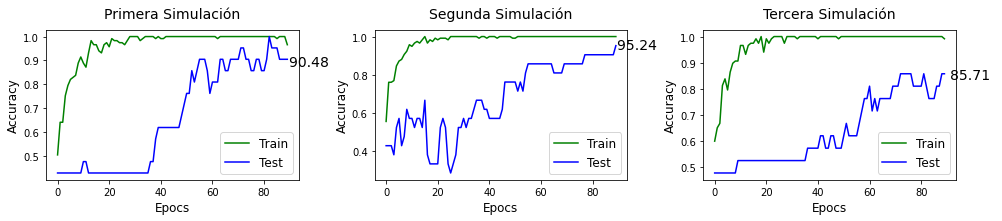

In [ ]:
fig=plt.figure(figsize=(16, 3.25))
fig.tight_layout()
fig.subplots_adjust(right=1.2, wspace=0.3, top=1.6, hspace=.3)
axs=plt.subplot(2,4,1)
axs.set_title('Primera Simulación',fontsize=14,pad=12)
axs.set_ylabel('Accuracy',rotation=90,labelpad=3,fontsize=12)
axs.set_xlabel('Epocs',fontsize=12)
axs.plot(hist.history['accuracy'], color='g')
axs.plot(hist.history['val_accuracy'], color='b')
axs.legend(['Train', 'Test'], loc='lower right',fontsize=12)
axs.annotate('%.2f '%(test*100),(10,0.8), # this is the point to label
                 textcoords="offset points",fontsize=14, # how to position the text
                 xytext=(228,18), # distance from text to points (x,y)
                 ha='center')

axs1=plt.subplot(2,4,2)
axs1.set_title('Segunda Simulación',fontsize=14,pad=12)
axs1.set_ylabel('Accuracy',rotation=90,labelpad=3,fontsize=12)
axs1.set_xlabel('Epocs',fontsize=12)
axs1.plot(hist1.history['accuracy'], color='g')
axs1.plot(hist1.history['val_accuracy'], color='b')
axs1.legend(['Train', 'Test'], loc='lower right',fontsize=12)
axs1.annotate('%.2f '%(test1*100),(10,0.8), # this is the point to label
                 textcoords="offset points",fontsize=14, # how to position the text
                 xytext=(227,26), # distance from text to points (x,y)
                 ha='center')
axs2=plt.subplot(2,4,3)
axs2.set_title('Tercera Simulación',fontsize=14,pad=12)
axs2.set_ylabel('Accuracy',rotation=90,labelpad=3,fontsize=12)
axs2.set_xlabel('Epocs',fontsize=12)
axs2.plot(hist2.history['accuracy'], color='g')
axs2.plot(hist2.history['val_accuracy'], color='b')
axs2.legend(['Train', 'Test'], loc='lower right',fontsize=12)
axs2.annotate('%.2f '%(test2*100),(10,0.8), # this is the point to label
                 textcoords="offset points",fontsize=14, # how to position the text
                 xytext=(232,10), # distance from text to points (x,y)
                 ha='center')

## CV-10Fold

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.0, random_state=1)

In [ ]:
#AD vs CN
n_folds = 10
kfold =StratifiedKFold(n_splits=10, shuffle=True, random_state=2)
histories,histories1,histories2=list(),list(),list()
models=list()
x_col,y_x=list(),list()
x_ter,y_ter=list(),list()
test,test1,test2=list(),list(),list()
for train_ix, val_ix in kfold.split(X_train,y_train):
    # select samples
    Xtrain, Ytrain = X_train[train_ix], y_train[train_ix]
    Xval, Yval = X_train[val_ix], y_train[val_ix]
    x_col.append(Xtrain)
    x_ter.append(Xval)
    y_x.append(Ytrain)
    y_ter.append(Yval)
    test_acc,history,model = evaluate_model(Xtrain,Ytrain,Xval,Yval)
    print('>%.3f' % test_acc)
    histories.append(history)
    test.append(test_acc)

    test_acc1,history1,model1 = evaluate_model(Xtrain,Ytrain,Xval,Yval)
    print('>%.3f' % test_acc1)
    histories1.append(history1)
    test1.append(test_acc1)

    test_acc2,history2,model2 = evaluate_model(Xtrain,Ytrain,Xval,Yval)
    print('>%.3f' % test_acc2)
    histories2.append(history2)
    test2.append(test_acc2)




Se han truncado las últimas 5000 líneas del flujo de salida.
4/4 - 0s - loss: 0.0046 - accuracy: 1.0000 - val_loss: 0.9492 - val_accuracy: 0.7857
Epoch 78/90
4/4 - 0s - loss: 0.0070 - accuracy: 1.0000 - val_loss: 0.9246 - val_accuracy: 0.7857
Epoch 79/90
4/4 - 0s - loss: 0.0043 - accuracy: 1.0000 - val_loss: 0.9308 - val_accuracy: 0.7857
Epoch 80/90
4/4 - 0s - loss: 0.0057 - accuracy: 1.0000 - val_loss: 0.9527 - val_accuracy: 0.8571
Epoch 81/90
4/4 - 0s - loss: 0.0061 - accuracy: 1.0000 - val_loss: 0.9582 - val_accuracy: 0.8571
Epoch 82/90
4/4 - 0s - loss: 0.0074 - accuracy: 1.0000 - val_loss: 0.8992 - val_accuracy: 0.8571
Epoch 83/90
4/4 - 0s - loss: 0.0039 - accuracy: 1.0000 - val_loss: 0.8564 - val_accuracy: 0.8571
Epoch 84/90
4/4 - 0s - loss: 0.0056 - accuracy: 1.0000 - val_loss: 0.8159 - val_accuracy: 0.8571
Epoch 85/90
4/4 - 0s - loss: 0.0034 - accuracy: 1.0000 - val_loss: 0.7871 - val_accuracy: 0.8571
Epoch 86/90
4/4 - 0s - loss: 0.0051 - accuracy: 1.0000 - val_loss: 0.7551 - va

In [ ]:
mean=statistics.mean(test)
mean1=statistics.mean(test1)
mean2=statistics.mean(test2)

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:14: MatplotlibDeprecationWarning: Unrecognized location 'lowwer rigth'. Falling back on 'best'; valid locations are
	best
	upper right
	upper left
	lower left
	lower right
	right
	center left
	center right
	lower center
	upper center
	center
This will raise an exception in 3.3.
  
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:22: MatplotlibDeprecationWarning: Unrecognized location 'lowwer rigth'. Falling back on 'best'; valid locations are
	best
	upper right
	upper left
	lower left
	lower right
	right
	center left
	center right
	lower center
	upper center
	center
This will raise an exception in 3.3.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:31: MatplotlibDeprecationWarning: Unrecognized location 'lowwer rigth'. Falling back on 'best'; valid locations are
	best
	upper right
	upper left
	lower left
	lower right
	right
	center left
	center right
	lower center
	upper center
	center
This will rais

Text(263, 12, '88.41 ')

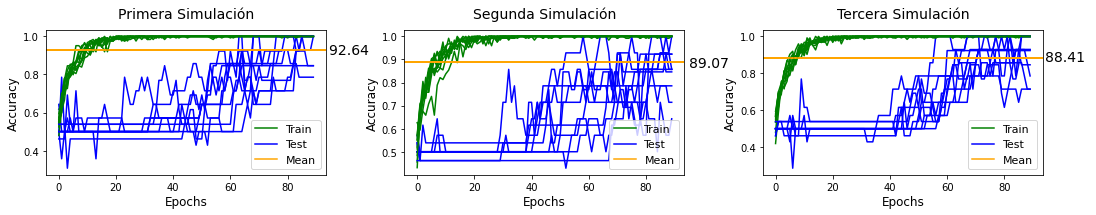

In [ ]:

fig, ((axs,axs1,axs2)) = plt.subplots(1,3,figsize=(12,1.5))
fig.tight_layout()

fig.subplots_adjust(right=1.2, wspace=0.28, top=1.6, hspace=0.3)
for i in range(len(histories)):
    axs.set_ylabel('Accuracy',fontsize=12,rotation=90,labelpad=3)
    axs.set_xlabel('Epochs',fontsize=12,labelpad=3)

    axs.set_title('Primera Simulación',fontsize=14,pad=12)
    axs.plot(histories[i].history['accuracy'], color='g')
    axs.plot(histories[i].history['val_accuracy'], color='b')
    axs.axhline(y=mean,label="media",color='orange')
    axs.legend(['Train', 'Test','Mean'], loc='lowwer rigth',fontsize=11)


    axs1.set_ylabel('Accuracy',fontsize=12,rotation=90,labelpad=3)
    axs1.set_xlabel('Epochs',fontsize=12,labelpad=3)
    axs1.plot(histories1[i].history['accuracy'], color='g')
    axs1.plot(histories1[i].history['val_accuracy'], color='b')
    axs1.axhline(y=mean1,label="media",color='orange')
    axs1.legend(['Train', 'Test','Mean'], loc='lowwer rigth',fontsize=11)


    axs1.set_title('Segunda Simulación',fontsize=14,pad=12)
    axs2.set_ylabel('Accuracy',fontsize=12,rotation=90,labelpad=3)
    axs2.set_xlabel('Epochs',fontsize=12,labelpad=3)
    axs2.plot(histories2[i].history['accuracy'], color='g')
    axs2.plot(histories2[i].history['val_accuracy'], color='b')
    axs2.axhline(y=mean2,label="media",color='orange')
    axs2.legend(['Train', 'Test','Mean'], loc='lowwer rigth',fontsize=11)

    axs2.set_title('Tercera Simulación',fontsize=14,pad=12)

axs1.annotate('%.2f '%(mean1*100),(10,0.8), # this is the point to label
                  textcoords="offset points",fontsize=14, # how to position the text
                  xytext=(265,15), # distance from text to points (x,y)
                  ha='center')
axs.annotate('%.2f '%(mean*100),(10,0.8), # this is the point to label
                  textcoords="offset points",fontsize=14, # how to position the text
                  xytext=(264,20), # distance from text to points (x,y)
                  ha='center')
axs2.annotate('%.2f '%(mean2*100),(10,0.8), # this is the point to label
                  textcoords="offset points",fontsize=14, # how to position the text
                  xytext=(263,12), # distance from text to points (x,y)
                  ha='center')


## Ensambles

In [ ]:
def votacion_por_mayoria(l):
  j=0
  res=[]
  while j<len(l[0]):
    i=0
    cont_uno=0
    cont_cero=0
    while i<len(l):
          if l[i][j]==1:
            cont_uno=cont_uno+1
          else:
            cont_cero=cont_cero+1
          i=i+1
    if cont_uno>=cont_cero:
        res.append(1)
    else:
        res.append(0)
    j=j+1
  return res

In [ ]:
def ensemble_predictions_voting_majority(members, testX,testy):
    i=0
    predictions=list()
    yhats = [model.predict_classes(testX) for model in members]
    yhats = array(yhats)
    # sum across ensemble members
    while i<len(yhats):
        predictions.append(tuple(yhats[i]))
        i=i+1
    voting_majority=votacion_por_mayoria(predictions)
    return accuracy_score(testy, voting_majority)

In [ ]:
### CV-10 Fold con el conjunto
scores_test,scores_test1,scores_test2,scores_ensembles,all_models,all_prediciton,all_test= list(),list(),list(),list(),list(),list(),list()
i=0
while i<10:
    yhats,models=list(),list()
    j=0
    while j<20:
      test_acc,history,model = evaluate_model(x_col[i], y_x[i], x_ter[i], y_ter[i])
      print('>%.3f' % test_acc)
      y_pred=model.predict_classes(x_ter[i])
      yhats.append(y_pred)
      models.append(model)
      j=j+1

    prediccion_final=votacion_por_mayoria(yhats)
    test=accuracy_score(y_ter[i],prediccion_final)
    test1=recall_score(y_ter[i],prediccion_final)
    test2=specificity_score(y_ter[i],prediccion_final)
    all_prediciton.append(prediccion_final)
    all_test.append(y_ter[i])
    scores_ensemb=ensemble_predictions_voting_majority(models, x_ter[i],y_ter[i])
    scores_ensembles.append(scores_ensemb)
    all_models.append(models)
    scores_test.append(test)
    scores_test1.append(test1)
    scores_test2.append(test2)
    i=i+1

Se han truncado las últimas 5000 líneas del flujo de salida.
Epoch 48/90
4/4 - 0s - loss: 0.0177 - accuracy: 1.0000 - val_loss: 0.5849 - val_accuracy: 0.6923
Epoch 49/90
4/4 - 0s - loss: 0.0177 - accuracy: 1.0000 - val_loss: 0.5129 - val_accuracy: 0.6923
Epoch 50/90
4/4 - 0s - loss: 0.0132 - accuracy: 1.0000 - val_loss: 0.4571 - val_accuracy: 0.8462
Epoch 51/90
4/4 - 0s - loss: 0.0161 - accuracy: 1.0000 - val_loss: 0.4446 - val_accuracy: 0.7692
Epoch 52/90
4/4 - 0s - loss: 0.0139 - accuracy: 1.0000 - val_loss: 0.4406 - val_accuracy: 0.7692
Epoch 53/90
4/4 - 0s - loss: 0.0137 - accuracy: 1.0000 - val_loss: 0.4141 - val_accuracy: 0.7692
Epoch 54/90
4/4 - 0s - loss: 0.0152 - accuracy: 1.0000 - val_loss: 0.4040 - val_accuracy: 0.8462
Epoch 55/90
4/4 - 0s - loss: 0.0098 - accuracy: 1.0000 - val_loss: 0.3967 - val_accuracy: 0.8462
Epoch 56/90
4/4 - 0s - loss: 0.0120 - accuracy: 1.0000 - val_loss: 0.3628 - val_accuracy: 0.8462
Epoch 57/90
4/4 - 0s - loss: 0.0102 - accuracy: 1.0000 - val_loss:

In [ ]:
def ensemble_predictions_voting_majority1(members, testX):
    i=0
    predictions=list()
    yhats = [model.predict_classes(testX) for model in members]
    yhats = array(yhats)
    # sum across ensemble members
    while i<len(yhats):
        predictions.append(tuple(yhats[i]))
        i=i+1
    voting_majority=votacion_por_mayoria(predictions)
    return voting_majority

In [ ]:
def evaluate_n_members_voting_majority(members, n_members, testX, testy):
    # select a subset of members
    subset = members[:n_members]
    # make prediction
    voting_majority = ensemble_predictions_voting_majority1(subset, testX)

    # calculate accuracy
    return accuracy_score(testy, voting_majority)

In [ ]:

ensembles_por_modelos=list()
j=0
while j<10:
  print('> %d Validacion' % j)
  ensemble_scores_voting_majority = list()
  for i in range(1, 20+1):
      ensemble_score = evaluate_n_members_voting_majority(all_models[j], i, x_ter[j], y_ter[j])
      print('> %d:  ensemble=%.3f' % (i,  ensemble_score))
      ensemble_scores_voting_majority.append(ensemble_score)
  ensembles_por_modelos.append(ensemble_scores_voting_majority)
  j=j+1

> 0 Validacion
> 1:  ensemble=0.786
> 2:  ensemble=0.786
> 3:  ensemble=0.857
> 4:  ensemble=0.857
> 5:  ensemble=0.857
> 6:  ensemble=0.857
> 7:  ensemble=0.929
> 8:  ensemble=0.929
> 9:  ensemble=0.929
> 10:  ensemble=0.929
> 11:  ensemble=0.929
> 12:  ensemble=0.929
> 13:  ensemble=0.929
> 14:  ensemble=0.929
> 15:  ensemble=0.929
> 16:  ensemble=0.929
> 17:  ensemble=0.929
> 18:  ensemble=0.929
> 19:  ensemble=0.929
> 20:  ensemble=0.929
> 1 Validacion
> 1:  ensemble=1.000
> 2:  ensemble=1.000
> 3:  ensemble=1.000
> 4:  ensemble=1.000
> 5:  ensemble=0.929
> 6:  ensemble=0.929
> 7:  ensemble=0.929
> 8:  ensemble=0.929
> 9:  ensemble=0.929
> 10:  ensemble=0.929
> 11:  ensemble=0.929
> 12:  ensemble=0.929
> 13:  ensemble=0.929
> 14:  ensemble=1.000
> 15:  ensemble=1.000
> 16:  ensemble=1.000
> 17:  ensemble=1.000
> 18:  ensemble=1.000
> 19:  ensemble=1.000
> 20:  ensemble=1.000
> 2 Validacion
> 1:  ensemble=0.929
> 2:  ensemble=0.786
> 3:  ensemble=0.786
> 4:  ensemble=0.786
> 5:  ens

### Rendimiento

In [ ]:
accuracy_score(all_test,all_prediciton)

0.9051094890510949

In [ ]:
recall_score(all_test,all_prediciton)

0.9142857142857143

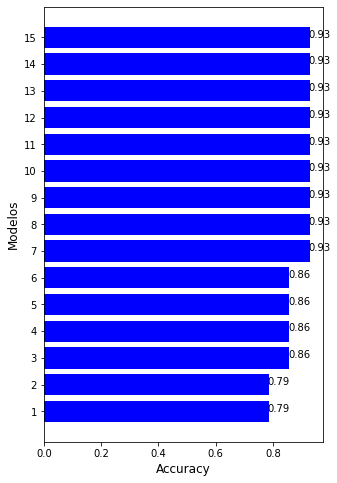

In [ ]:
y_pos = np.arange(len(all_models[0]))
plt.figure(figsize=(5,8))
plt.barh(y_pos, ensemble_scores_voting_majority[0],align='center',  color='b')
plt.ylabel('Modelos',fontsize=12)
plt.xlabel('Accuracy',fontsize=12)
for x,y in zip(ensemble_scores_voting_majority[0], y_pos):
    label = "{:.2f}".format(x)
    plt.annotate(label, # this is the text
                 (x,y), # this is the point to label
                 textcoords="offset points", # how to position the text
                 xytext=(12,0), # distance from text to points (x,y)
                 ha='center') # horizontal alignment can be left, right or center


plt.yticks(y_pos,all_models[0])

plt.show()

In [ ]:
medida=roc_auc_score(all_test,all_prediciton)
medida

0.9049040511727078

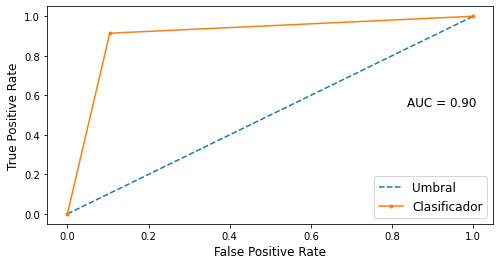

In [ ]:
# plot no skill roc curve
pyplot.figure(figsize=(8,4))
pyplot.plot([0, 1], [0, 1], linestyle='--', label='Umbral')
# calculate roc curve for model
fpr, tpr, _ = roc_curve(all_test,all_prediciton)
# plot model roc curve
pyplot.plot(fpr, tpr, marker='.', label='Clasificador')
# axis labels

pyplot.xlabel('False Positive Rate',fontsize=12)
pyplot.ylabel('True Positive Rate',fontsize=12)
# show the legend
pyplot.legend(fontsize=12)
plt.annotate('AUC = %.2f '%(medida),(1,0.8), # this is the point to label
                 textcoords="offset points",fontsize=12, # how to position the text
                 xytext=(-30,-50), # distance from text to points (x,y)
                 ha='center')
# show the plot
pyplot.show()

In [ ]:
def mostrar_resultados(y_test,pred_y):
  conf_matrix=confusion_matrix(y_test,pred_y)
  plt.figure(figsize=(10,6))
  sns.heatmap(conf_matrix,xticklabels= ("CN","AD"),yticklabels=("CN","AD"),annot=True, fmt="d",cmap='Set3_r')
  plt.title("Matrix Confussión")
  plt.ylabel("Real",fontsize=12)
  plt.xlabel("Predicho",fontsize=12)
  plt.show()
  print(classification_report(y_test,pred_y))

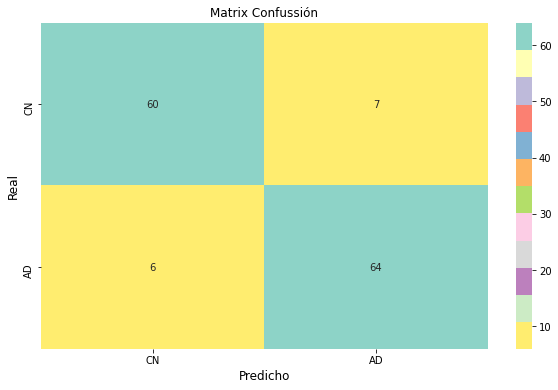

              precision    recall  f1-score   support

           0       0.91      0.90      0.90        67
           1       0.90      0.91      0.91        70

    accuracy                           0.91       137
   macro avg       0.91      0.90      0.91       137
weighted avg       0.91      0.91      0.91       137



In [ ]:
mostrar_resultados(all_test,all_prediciton)

#  MCI vs CN

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1)

In [ ]:
test4,hist4,model4=evaluate_model(X_train,y_train,X_test,y_test)
test5,hist5,model5=evaluate_model(X_train,y_train,X_test,y_test)
test6,hist6,model6=evaluate_model(X_train,y_train,X_test,y_test)


Epoch 1/90
5/5 - 11s - loss: 1.1893 - accuracy: 0.5066 - val_loss: 0.6834 - val_accuracy: 0.7037 - 11s/epoch - 2s/step
Epoch 2/90
5/5 - 1s - loss: 0.7949 - accuracy: 0.6118 - val_loss: 0.7027 - val_accuracy: 0.2963 - 649ms/epoch - 130ms/step
Epoch 3/90
5/5 - 1s - loss: 0.7926 - accuracy: 0.6447 - val_loss: 0.7363 - val_accuracy: 0.2963 - 598ms/epoch - 120ms/step
Epoch 4/90
5/5 - 1s - loss: 0.6606 - accuracy: 0.7171 - val_loss: 0.8499 - val_accuracy: 0.2963 - 532ms/epoch - 106ms/step
Epoch 5/90
5/5 - 1s - loss: 0.7164 - accuracy: 0.6776 - val_loss: 0.9988 - val_accuracy: 0.2963 - 624ms/epoch - 125ms/step
Epoch 6/90
5/5 - 1s - loss: 0.5434 - accuracy: 0.7632 - val_loss: 1.1408 - val_accuracy: 0.2963 - 581ms/epoch - 116ms/step
Epoch 7/90
5/5 - 1s - loss: 0.5422 - accuracy: 0.7434 - val_loss: 1.2981 - val_accuracy: 0.2963 - 604ms/epoch - 121ms/step
Epoch 8/90
5/5 - 1s - loss: 0.5357 - accuracy: 0.7763 - val_loss: 1.3807 - val_accuracy: 0.2963 - 586ms/epoch - 117ms/step
Epoch 9/90
5/5 - 1s 

Text(232, 10, '66.67 ')

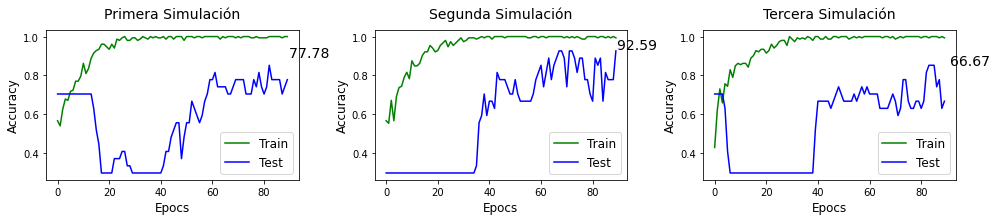

In [ ]:
fig=plt.figure(figsize=(16, 3.25))
fig.tight_layout()
fig.subplots_adjust(right=1.2, wspace=0.3, top=1.6, hspace=.3)
axs=plt.subplot(2,4,1)
axs.set_title('Primera Simulación',fontsize=14,pad=12)
axs.set_ylabel('Accuracy',rotation=90,labelpad=3,fontsize=12)
axs.set_xlabel('Epocs',fontsize=12)
axs.plot(hist12.history['accuracy'], color='g')
axs.plot(hist12.history['val_accuracy'], color='b')
axs.legend(['Train', 'Test'], loc='lower right',fontsize=12)
axs.annotate('%.2f '%(test12*100),(10,0.8), # this is the point to label
                 textcoords="offset points",fontsize=14, # how to position the text
                 xytext=(228,18), # distance from text to points (x,y)
                 ha='center')

axs1=plt.subplot(2,4,2)
axs1.set_title('Segunda Simulación',fontsize=14,pad=12)
axs1.set_ylabel('Accuracy',rotation=90,labelpad=3,fontsize=12)
axs1.set_xlabel('Epocs',fontsize=12)
axs1.plot(hist.history['accuracy'], color='g')
axs1.plot(hist.history['val_accuracy'], color='b')
axs1.legend(['Train', 'Test'], loc='lower right',fontsize=12)
axs1.annotate('%.2f '%(test*100),(10,0.8), # this is the point to label
                 textcoords="offset points",fontsize=14, # how to position the text
                 xytext=(227,26), # distance from text to points (x,y)
                 ha='center')
axs2=plt.subplot(2,4,3)
axs2.set_title('Tercera Simulación',fontsize=14,pad=12)
axs2.set_ylabel('Accuracy',rotation=90,labelpad=3,fontsize=12)
axs2.set_xlabel('Epocs',fontsize=12)
axs2.plot(hist1.history['accuracy'], color='g')
axs2.plot(hist1.history['val_accuracy'], color='b')
axs2.legend(['Train', 'Test'], loc='lower right',fontsize=12)
axs2.annotate('%.2f '%(test1*100),(10,0.8), # this is the point to label
                 textcoords="offset points",fontsize=14, # how to position the text
                 xytext=(232,10), # distance from text to points (x,y)
                 ha='center')

## CV-10Fold

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.0, random_state=1)

In [ ]:
#MCI vs CN
n_folds = 10
kfold =StratifiedKFold(n_splits=10, shuffle=True, random_state=2)
histories,histories1,histories2=list(),list(),list()
models=list()
x_col,y_x=list(),list()
x_ter,y_ter=list(),list()
test,test1,test2=list(),list(),list()
for train_ix, val_ix in kfold.split(X_train,y_train):
    # select samples
    Xtrain, Ytrain = X_train[train_ix], y_train[train_ix]
    Xval, Yval = X_train[val_ix], y_train[val_ix]
    x_col.append(Xtrain)
    x_ter.append(Xval)
    y_x.append(Ytrain)
    y_ter.append(Yval)
    test_acc,history,model = evaluate_model(Xtrain,Ytrain,Xval,Yval)
    print('>%.3f' % test_acc)
    histories.append(history)
    test.append(test_acc)

    test_acc1,history1,model1 = evaluate_model(Xtrain,Ytrain,Xval,Yval)
    print('>%.3f' % test_acc1)
    histories1.append(history1)
    test1.append(test_acc1)

    test_acc2,history2,model2 = evaluate_model(Xtrain,Ytrain,Xval,Yval)
    print('>%.3f' % test_acc2)
    histories2.append(history2)
    test2.append(test_acc2)

Se han truncado las últimas 5000 líneas del flujo de salida.
Epoch 35/90
5/5 - 0s - loss: 0.0449 - accuracy: 1.0000 - val_loss: 0.7249 - val_accuracy: 0.5556 - 276ms/epoch - 55ms/step
Epoch 36/90
5/5 - 0s - loss: 0.0468 - accuracy: 1.0000 - val_loss: 0.7912 - val_accuracy: 0.6111 - 280ms/epoch - 56ms/step
Epoch 37/90
5/5 - 0s - loss: 0.0367 - accuracy: 1.0000 - val_loss: 0.7878 - val_accuracy: 0.6111 - 273ms/epoch - 55ms/step
Epoch 38/90
5/5 - 0s - loss: 0.0370 - accuracy: 1.0000 - val_loss: 0.8734 - val_accuracy: 0.5556 - 280ms/epoch - 56ms/step
Epoch 39/90
5/5 - 0s - loss: 0.0319 - accuracy: 1.0000 - val_loss: 0.9780 - val_accuracy: 0.5000 - 275ms/epoch - 55ms/step
Epoch 40/90
5/5 - 0s - loss: 0.0334 - accuracy: 0.9937 - val_loss: 1.0058 - val_accuracy: 0.5000 - 274ms/epoch - 55ms/step
Epoch 41/90
5/5 - 0s - loss: 0.0292 - accuracy: 1.0000 - val_loss: 1.0237 - val_accuracy: 0.5000 - 275ms/epoch - 55ms/step
Epoch 42/90
5/5 - 0s - loss: 0.0256 - accuracy: 1.0000 - val_loss: 1.0367 - va

In [ ]:
mean=statistics.mean(test)
mean1=statistics.mean(test1)
mean2=statistics.mean(test2)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:14: MatplotlibDeprecationWarning: Unrecognized location 'lowwer rigth'. Falling back on 'best'; valid locations are
	best
	upper right
	upper left
	lower left
	lower right
	right
	center left
	center right
	lower center
	upper center
	center
This will raise an exception in 3.3.
  
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:22: MatplotlibDeprecationWarning: Unrecognized location 'lowwer rigth'. Falling back on 'best'; valid locations are
	best
	upper right
	upper left
	lower left
	lower right
	right
	center left
	center right
	lower center
	upper center
	center
This will raise an exception in 3.3.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:31: MatplotlibDeprecationWarning: Unrecognized location 'lowwer rigth'. Falling back on 'best'; valid locations are
	best
	upper right
	upper left
	lower left
	lower right
	right
	center left
	center right
	lower center
	upper center
	center
This will rais

Text(263, 22, '71.50 ')

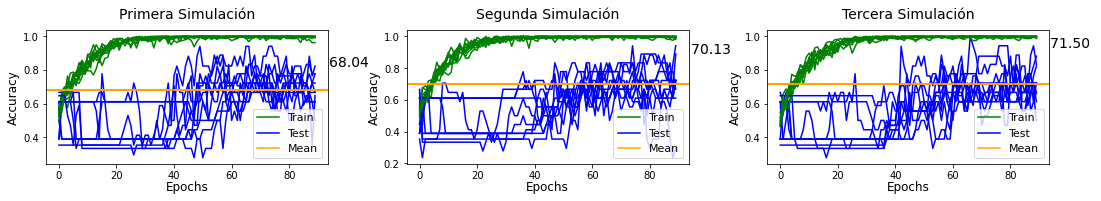

In [ ]:

fig, ((axs,axs1,axs2)) = plt.subplots(1,3,figsize=(12,1.4))
fig.tight_layout()

fig.subplots_adjust(right=1.2, wspace=0.28, top=1.6, hspace=0.3)
for i in range(len(histories6)):
    axs.set_ylabel('Accuracy',fontsize=12,rotation=90,labelpad=3)
    axs.set_xlabel('Epochs',fontsize=12,labelpad=0)

    axs.set_title('Primera Simulación',fontsize=14,pad=12)
    axs.plot(histories[i].history['accuracy'], color='g')
    axs.plot(histories[i].history['val_accuracy'], color='b')
    axs.axhline(y=mean,label="media",color='orange')
    axs.legend(['Train', 'Test','Mean'], loc='lowwer rigth',fontsize=11)


    axs1.set_ylabel('Accuracy',fontsize=12,rotation=90,labelpad=3)
    axs1.set_xlabel('Epochs',fontsize=12,labelpad=0)
    axs1.plot(histories1[i].history['accuracy'], color='g')
    axs1.plot(histories1[i].history['val_accuracy'], color='b')
    axs1.axhline(y=mean1,label="media",color='orange')
    axs1.legend(['Train', 'Test','Mean'], loc='lowwer rigth',fontsize=11)


    axs1.set_title('Segunda Simulación',fontsize=14,pad=12)
    axs2.set_ylabel('Accuracy',fontsize=12,rotation=90,labelpad=3)
    axs2.set_xlabel('Epochs',fontsize=12,labelpad=0)
    axs2.plot(histories2[i].history['accuracy'], color='g')
    axs2.plot(histories2[i].history['val_accuracy'], color='b')
    axs2.axhline(y=mean2,label="media",color='orange')
    axs2.legend(['Train', 'Test','Mean'], loc='lowwer rigth',fontsize=11)

    axs2.set_title('Tercera Simulación',fontsize=14,pad=12)

axs1.annotate('%.2f '%(mean1*100),(10,0.8), # this is the point to label
                  textcoords="offset points",fontsize=14, # how to position the text
                  xytext=(265,15), # distance from text to points (x,y)
                  ha='center')
axs.annotate('%.2f '%(mean*100),(10,0.8), # this is the point to label
                  textcoords="offset points",fontsize=14, # how to position the text
                  xytext=(264,3), # distance from text to points (x,y)
                  ha='center')
axs2.annotate('%.2f '%(mean2*100),(10,0.8), # this is the point to label
                  textcoords="offset points",fontsize=14, # how to position the text
                  xytext=(263,22), # distance from text to points (x,y)
                  ha='center')

## Ensambles

In [ ]:
### CV-10 Fold con el conjunto
scores_test,scores_test1,scores_test2,scores_ensembles,all_models,all_prediciton,all_test= list(),list(),list(),list(),list(),list(),list()
i=0
while i<10:
    yhats,models=list(),list()
    j=0
    while j<20:
      test_acc,history,model = evaluate_model(x_col[i], y_x[i], x_ter[i], y_ter[i])
      print('>%.3f' % test_acc)
      y_pred=model.predict_classes(x_ter[i])
      yhats.append(y_pred)
      models.append(model)
      j=j+1

    prediccion_final=votacion_por_mayoria(yhats)
    test=accuracy_score(y_ter[i],prediccion_final)
    test1=recall_score(y_ter[i],prediccion_final)
    test2=specificity_score(y_ter[i],prediccion_final)
    all_prediciton.append(prediccion_final)
    all_test.append(y_ter[i])
    scores_ensemb=ensemble_predictions_voting_majority(models, x_ter[i],y_ter[i])
    scores_ensembles.append(scores_ensemb)
    all_models.append(models)
    scores_test.append(test)
    scores_test1.append(test1)
    scores_test2.append(test2)
    i=i+1

Se han truncado las últimas 5000 líneas del flujo de salida.
Epoch 48/90
6/6 - 0s - loss: 0.0572 - accuracy: 1.0000 - val_loss: 1.8809 - val_accuracy: 0.4706
Epoch 49/90
6/6 - 0s - loss: 0.0389 - accuracy: 0.9938 - val_loss: 1.3019 - val_accuracy: 0.5882
Epoch 50/90
6/6 - 0s - loss: 0.0337 - accuracy: 0.9938 - val_loss: 1.1230 - val_accuracy: 0.5882
Epoch 51/90
6/6 - 0s - loss: 0.0300 - accuracy: 0.9938 - val_loss: 1.1005 - val_accuracy: 0.7059
Epoch 52/90
6/6 - 0s - loss: 0.0265 - accuracy: 0.9938 - val_loss: 1.2434 - val_accuracy: 0.5882
Epoch 53/90
6/6 - 0s - loss: 0.0357 - accuracy: 0.9938 - val_loss: 1.1715 - val_accuracy: 0.5882
Epoch 54/90
6/6 - 0s - loss: 0.0258 - accuracy: 1.0000 - val_loss: 1.1581 - val_accuracy: 0.5882
Epoch 55/90
6/6 - 0s - loss: 0.0257 - accuracy: 0.9938 - val_loss: 1.1140 - val_accuracy: 0.6471
Epoch 56/90
6/6 - 0s - loss: 0.0290 - accuracy: 0.9876 - val_loss: 1.1537 - val_accuracy: 0.6471
Epoch 57/90
6/6 - 0s - loss: 0.0243 - accuracy: 0.9938 - val_loss:

In [ ]:
#MCI vs CN
ensembles_por_modelos=list()
j=0
while j<10:
  print('> %d Validacion' % j)
  ensemble_scores_voting_majority = list()
  for i in range(1, 17+1):
      ensemble_score = evaluate_n_members_voting_majority(all_models[j], i, x_ter[j], y_ter[j])
      print('> %d:  ensemble=%.3f' % (i,  ensemble_score))
      ensemble_scores_voting_majority.append(ensemble_score)
  ensembles_por_modelos.append(ensemble_scores_voting_majority)
  j=j+1

> 0 Validacion
> 1:  ensemble=0.611
> 2:  ensemble=0.667
> 3:  ensemble=0.611
> 4:  ensemble=0.611
> 5:  ensemble=0.667
> 6:  ensemble=0.722
> 7:  ensemble=0.722
> 8:  ensemble=0.722
> 9:  ensemble=0.722
> 10:  ensemble=0.722
> 11:  ensemble=0.667
> 12:  ensemble=0.722
> 13:  ensemble=0.722
> 14:  ensemble=0.722
> 15:  ensemble=0.722
> 16:  ensemble=0.722
> 17:  ensemble=0.722
> 1 Validacion
> 1:  ensemble=0.722
> 2:  ensemble=0.611
> 3:  ensemble=0.722
> 4:  ensemble=0.778
> 5:  ensemble=0.722
> 6:  ensemble=0.778
> 7:  ensemble=0.722
> 8:  ensemble=0.778
> 9:  ensemble=0.778
> 10:  ensemble=0.778
> 11:  ensemble=0.778
> 12:  ensemble=0.722
> 13:  ensemble=0.722
> 14:  ensemble=0.722
> 15:  ensemble=0.722
> 16:  ensemble=0.722
> 17:  ensemble=0.722
> 2 Validacion
> 1:  ensemble=0.722
> 2:  ensemble=0.667
> 3:  ensemble=0.722
> 4:  ensemble=0.667
> 5:  ensemble=0.722
> 6:  ensemble=0.667
> 7:  ensemble=0.667
> 8:  ensemble=0.667
> 9:  ensemble=0.667
> 10:  ensemble=0.667
> 11:  ensembl

### Rendimiento

In [ ]:
accuracy_score(all_test,all_prediciton)

0.7191011235955056

In [ ]:
recall_score(all_test,all_prediciton)

0.8378378378378378

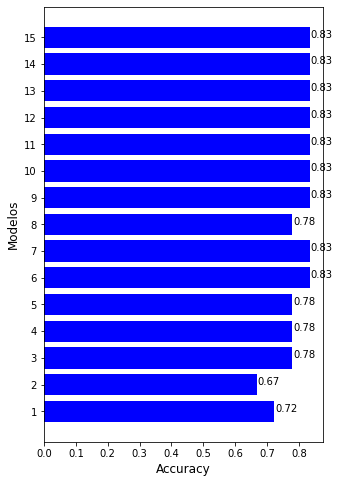

In [ ]:
y_pos = np.arange(len(all_models[0]))
plt.figure(figsize=(5,8))
plt.barh(y_pos, ensemble_scores_voting_majority[0],align='center',  color='b')
plt.ylabel('Modelos',fontsize=12)
plt.xlabel('Accuracy',fontsize=12)
for x,y in zip(ensemble_scores_voting_majority[0], y_pos):
    label = "{:.2f}".format(x)
    plt.annotate(label, # this is the text
                 (x,y), # this is the point to label
                 textcoords="offset points", # how to position the text
                 xytext=(12,0), # distance from text to points (x,y)
                 ha='center') # horizontal alignment can be left, right or center


plt.yticks(y_pos,all_models[0])

plt.show()

In [ ]:
medida=roc_auc_score(all_test,all_prediciton)
medida

0.6801129487696651

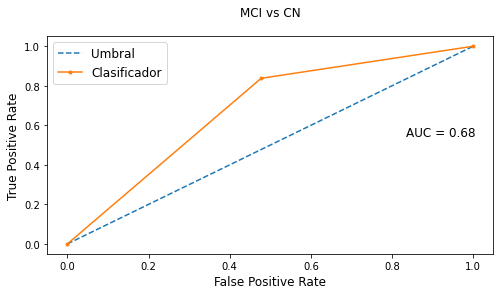

In [ ]:
# plot no skill roc curve
pyplot.figure(figsize=(8,4))
pyplot.plot([0, 1], [0, 1], linestyle='--', label='Umbral')
# calculate roc curve for model
fpr, tpr, _ = roc_curve(all_test,all_prediciton)
# plot model roc curve
pyplot.plot(fpr, tpr, marker='.', label='Clasificador')
# axis labels
plt.title("MCI vs CN",fontsize=12,pad=20)
pyplot.xlabel('False Positive Rate',fontsize=12)
pyplot.ylabel('True Positive Rate',fontsize=12)
# show the legend
pyplot.legend(fontsize=12)
plt.annotate('AUC = %.2f '%(medida),(1,0.8), # this is the point to label
                 textcoords="offset points",fontsize=12, # how to position the text
                 xytext=(-30,-50), # distance from text to points (x,y)
                 ha='center')
# show the plot
pyplot.show()

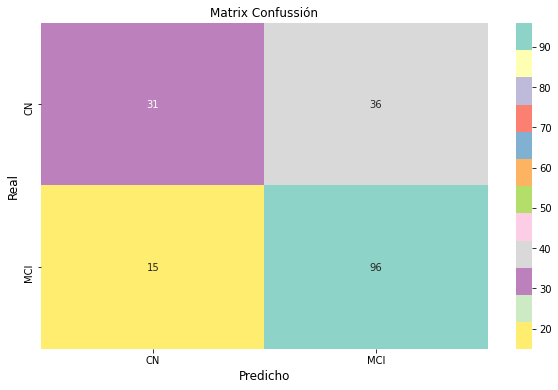

              precision    recall  f1-score   support

           0       0.67      0.46      0.55        67
           1       0.73      0.86      0.79       111

    accuracy                           0.71       178
   macro avg       0.70      0.66      0.67       178
weighted avg       0.71      0.71      0.70       178



In [ ]:
mostrar_resultados1(all_test,all_prediciton)